In [50]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

## 1. Load dataset and EDA

In [3]:
wine = load_wine()

X = wine.data
y = wine.target

In [6]:
feature_names = wine.feature_names
target_names = wine.target_names

In [7]:
# Build df

df = pd.DataFrame(X, columns=feature_names)
df["class"] = y

In [8]:
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  class

There are no null values.

In [11]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


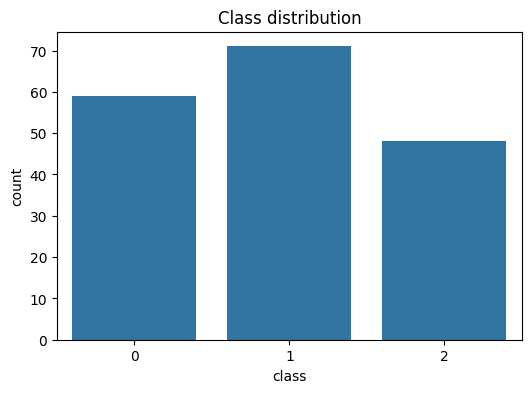

In [12]:
# Class imbalances?

plt.figure(figsize=(6,4))
sns.countplot(x="class", data=df)
plt.title("Class distribution")
plt.show()

Classes are slightly unbalanced.

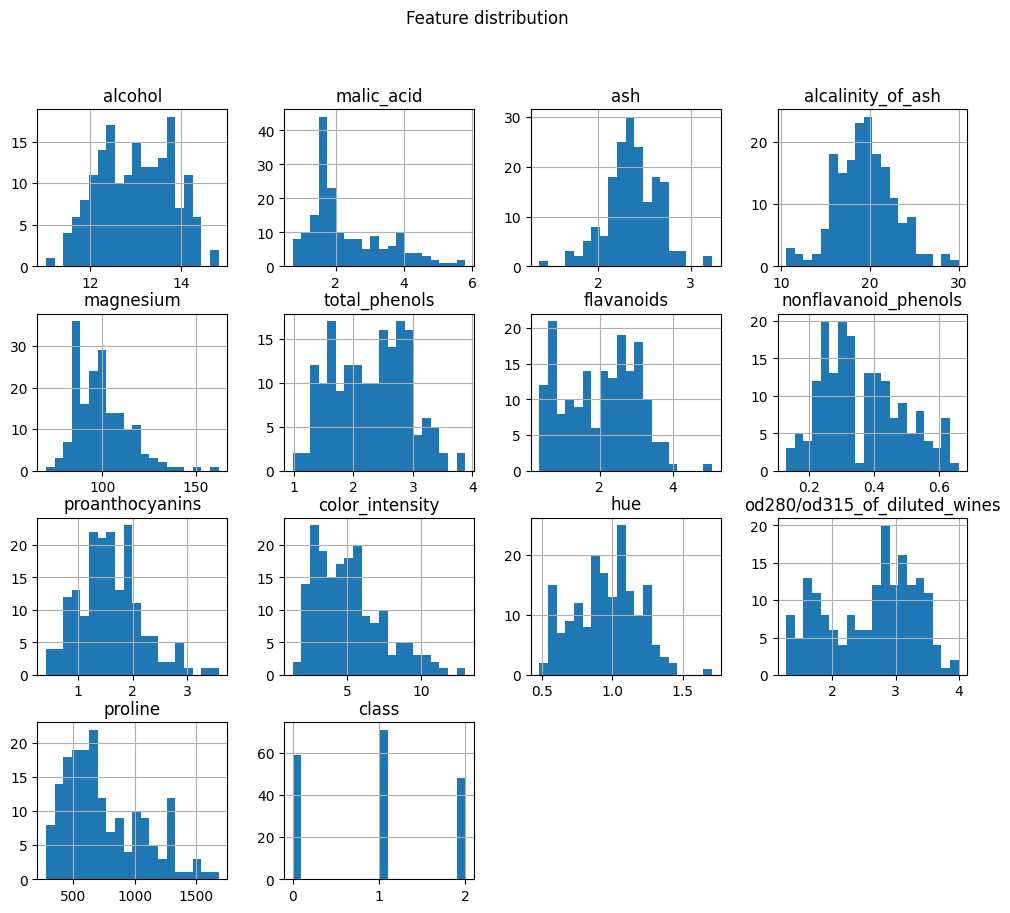

In [13]:
# Features distributions

df.hist(figsize=(12,10), bins=20)
plt.suptitle("Feature distribution")
plt.show()

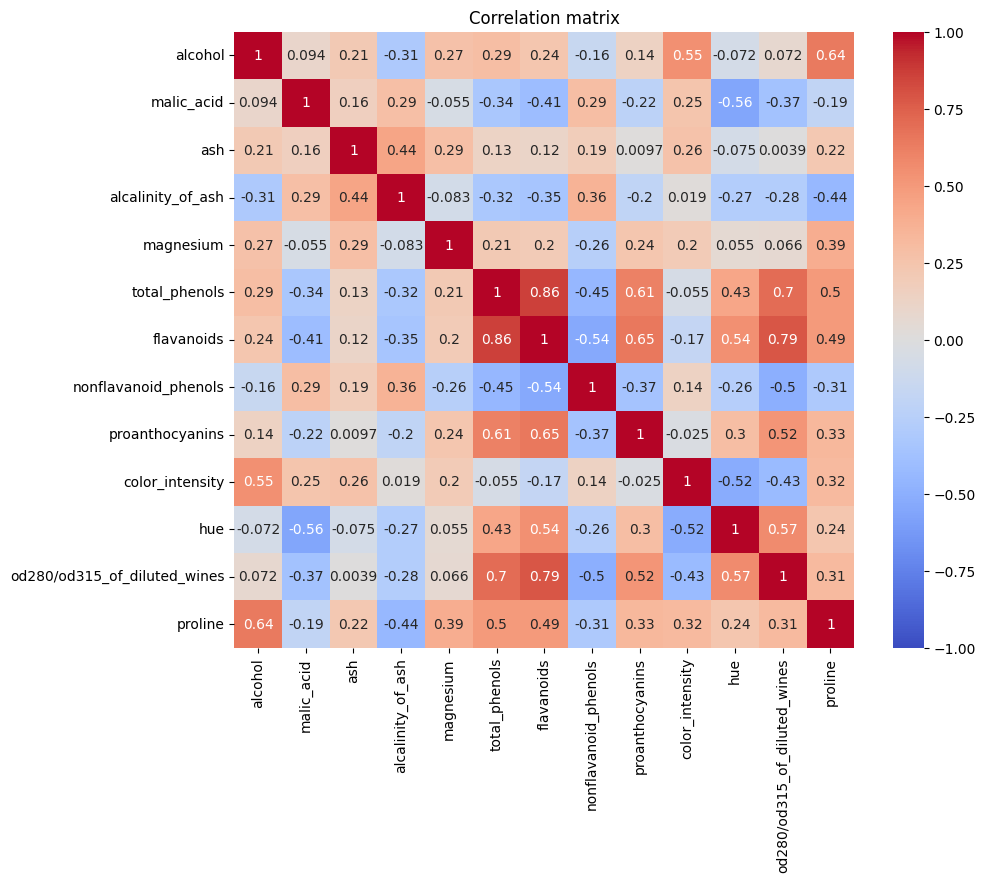

In [16]:
# Correlation matrix

plt.figure(figsize=(10,8))
sns.heatmap(df.drop(columns=["class"]).corr(), cmap="coolwarm", annot=True, vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.show()

Since some features are strongly correlated, we can consider a dimensionality reduction to avoid redundancy.

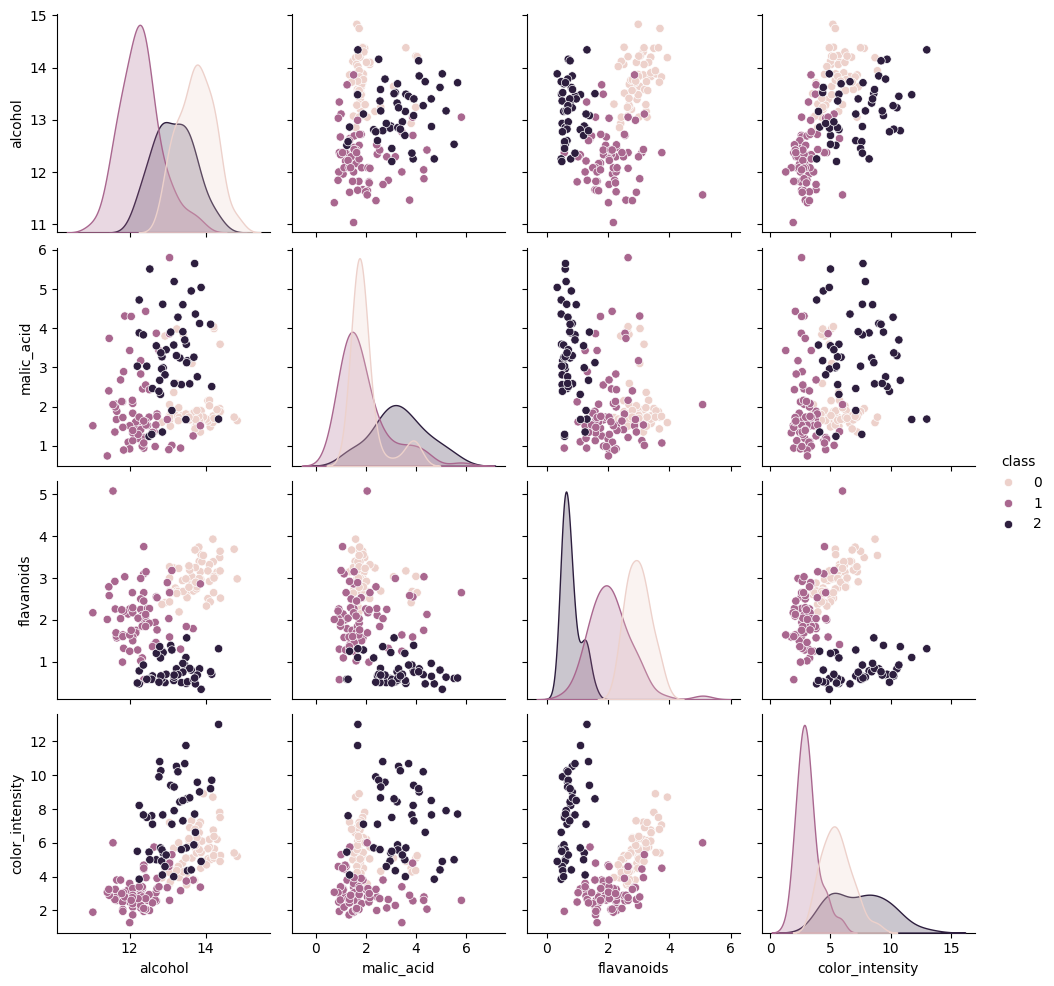

In [17]:
# Classes separation with respect to some features

selected_features = ["alcohol", "malic_acid", "flavanoids", "color_intensity"]

sns.pairplot(df[selected_features + ["class"]], hue="class", diag_kind="kde")
plt.show()

Some classes (for instance flavonoids and color_intensity) are well separated.

The diagonal distributions show that some features have different spread across classes. LDA assumes equal covariance matrices across classes, but moderate deviations are still acceptable. 

## 2. Pre-processing

In [20]:
# Separe target and features

X = df.drop(columns=["class"])
y = df["class"]

In [23]:
# Test train split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
print(X_train.shape)
print(X_test.shape)

(142, 13)
(36, 13)


In [25]:
# Features scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. LDA

In [26]:
# Train the model

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)

LinearDiscriminantAnalysis()

In [28]:
# Predictions and evaluations

y_pred = lda.predict(X_test_scaled)

print("Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy:  0.9444444444444444
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       0.93      0.93      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



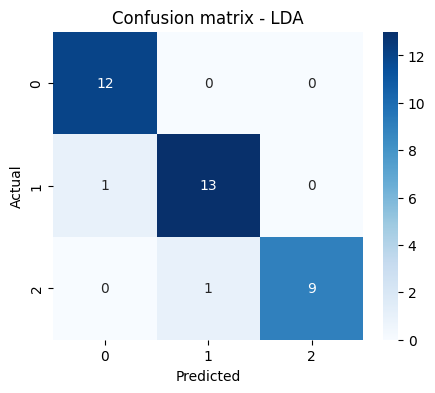

In [29]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix - LDA")
plt.show()

LDA achieves high accuracy (94%) on the test set, and samples are almost always well classified.

## 4. Visualizations: projection and explained variance

In [30]:
# Fit LDA for dimensionality reduction

lda_vis = LinearDiscriminantAnalysis(n_components=2)

X_lda = lda_vis.fit_transform(X_train_scaled, y_train)

In [32]:
X_lda.shape

(142, 2)

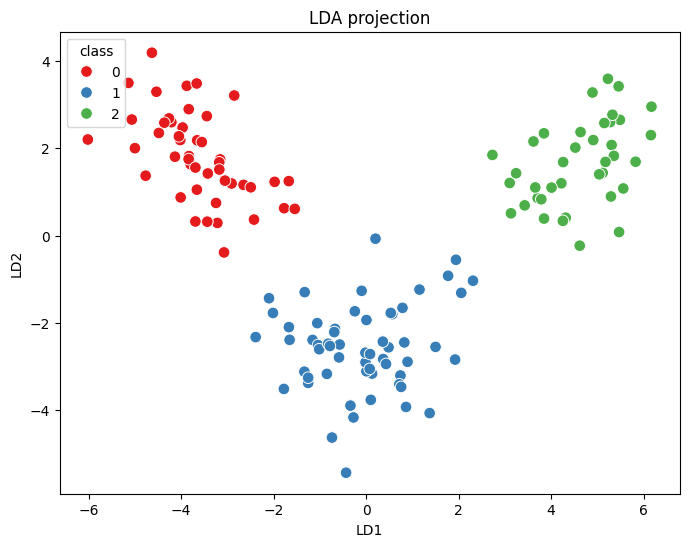

In [45]:
# Plot

lda_df = pd.DataFrame(X_lda, columns=["LD1", "LD2"])
lda_df["class"] = y_train.values

plt.figure(figsize=(8,6))

sns.scatterplot(data=lda_df, x="LD1", y="LD2", hue="class", palette="Set1", s=70)
plt.title("LDA projection")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.show()

Classes are clearly separated along LD1, but classes 0 and 2 are not separated along LD2. One dimension is enough to separate classes.

In [39]:
# Which features contribute the most to LD1 and LD2?

coef_df = pd.DataFrame(lda_vis.scalings_, index=X.columns, columns=["LD1", "LD2"])
coef_df

,LD1,LD2
alcohol,-0.223242,0.564537
malic_acid,0.221767,0.521084
ash,-0.045359,0.649374
alcalinity_of_ash,0.498103,-0.525926
magnesium,-0.086171,-0.015686
total_phenols,0.552559,-0.008666
flavanoids,-2.230900,-0.372870
nonflavanoid_phenols,-0.235595,-0.085156
proanthocyanins,0.230528,-0.280477
color_intensity,0.776629,0.810022


In [40]:
coef_df["LD1"].abs().sort_values(ascending=False)

flavanoids                      2.230900
proline                         0.841489
color_intensity                 0.776629
od280/od315_of_diluted_wines    0.727885
total_phenols                   0.552559
alcalinity_of_ash               0.498103
nonflavanoid_phenols            0.235595
proanthocyanins                 0.230528
alcohol                         0.223242
malic_acid                      0.221767
hue                             0.117786
magnesium                       0.086171
ash                             0.045359
Name: LD1, dtype: float64

In [41]:
coef_df["LD2"].abs().sort_values(ascending=False)

proline                         0.919084
color_intensity                 0.810022
ash                             0.649374
alcohol                         0.564537
alcalinity_of_ash               0.525926
malic_acid                      0.521084
flavanoids                      0.372870
proanthocyanins                 0.280477
hue                             0.164207
od280/od315_of_diluted_wines    0.107304
nonflavanoid_phenols            0.085156
magnesium                       0.015686
total_phenols                   0.008666
Name: LD2, dtype: float64

Features with larger absolute coefficients have stronger influence on the LD1 and LD2 respectively.

For example: $LD1 = -0.22 \cdot alcohol + 0.22 \cdot malic_acid + ... $

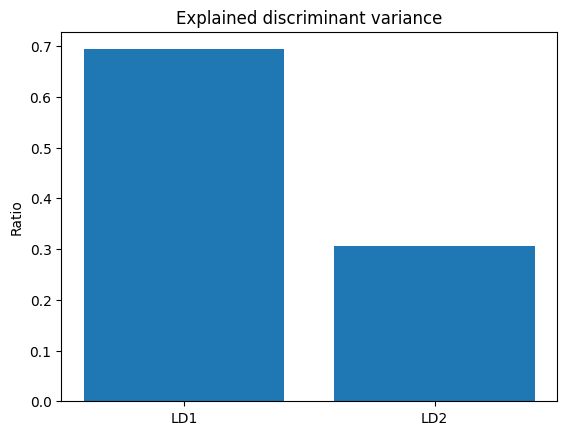

In [38]:
# How much information captures each discriminant component?

var_ratio = lda_vis.explained_variance_ratio_

plt.bar(["LD1", "LD2"], var_ratio)
plt.title("Explained discriminant variance")
plt.ylabel("Ratio")
plt.show()

## 5. Comparison with PCA

In [43]:
# PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

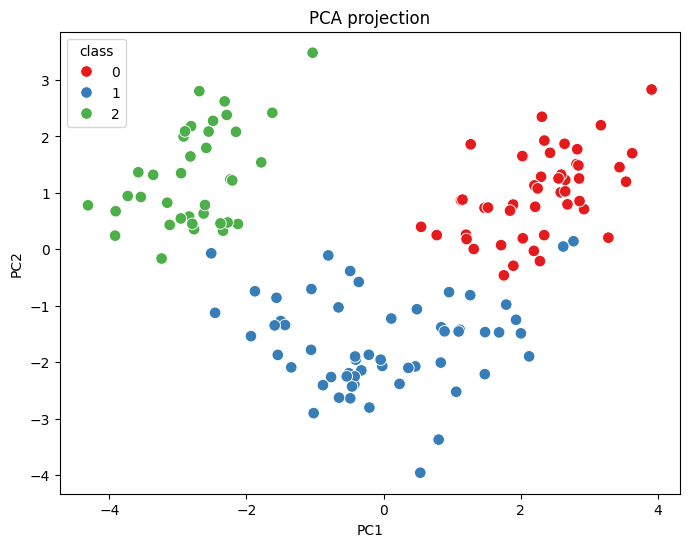

In [44]:
# Plot

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["class"] = y_train.values

plt.figure(figsize=(8,6))

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="class", palette="Set1", s=70)
plt.title("PCA projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Classes are more overlapped with respect to LDA. PCA only looks for directions of max variance, ignoring class labels. LDA instead maximized class separability. Indeed:

* PCA = unsupervised
* LDA = supervised

## 6. Comparison with QDA

In [48]:
# QDA

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_scaled, y_train)

QuadraticDiscriminantAnalysis()

In [49]:
# Predictions and performance

y_pred_qda = qda.predict(X_test_scaled)

print("Accuracy: ", accuracy_score(y_test, y_pred_qda))
print(classification_report(y_test, y_pred_qda))

Accuracy:  1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



Both LDA and QDA achieve high accuracy on the test set. This means that wine dataset is highly separable in the feature space. However, the dataset is very small, so a perfect accuracy must be considered with caution.

## 7. Cross validation 

In [51]:
lda_cv = cross_val_score(lda, X_train_scaled, y_train, cv=5)
qda_cv = cross_val_score(qda, X_train_scaled, y_train, cv=5)

print("LDA CV mean: ", lda_cv.mean())
print("QDA CV mean: ", qda_cv.mean())

LDA CV mean:  0.9928571428571429
QDA CV mean:  0.9788177339901478


This estimation is more stable.